<a href="https://colab.research.google.com/github/maxF10R35/Estudio-Aguacates-Monarca/blob/main/predicci%C3%B3n_del_clima_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estacionario: [0.34615385 0.57692308 0.07692308]


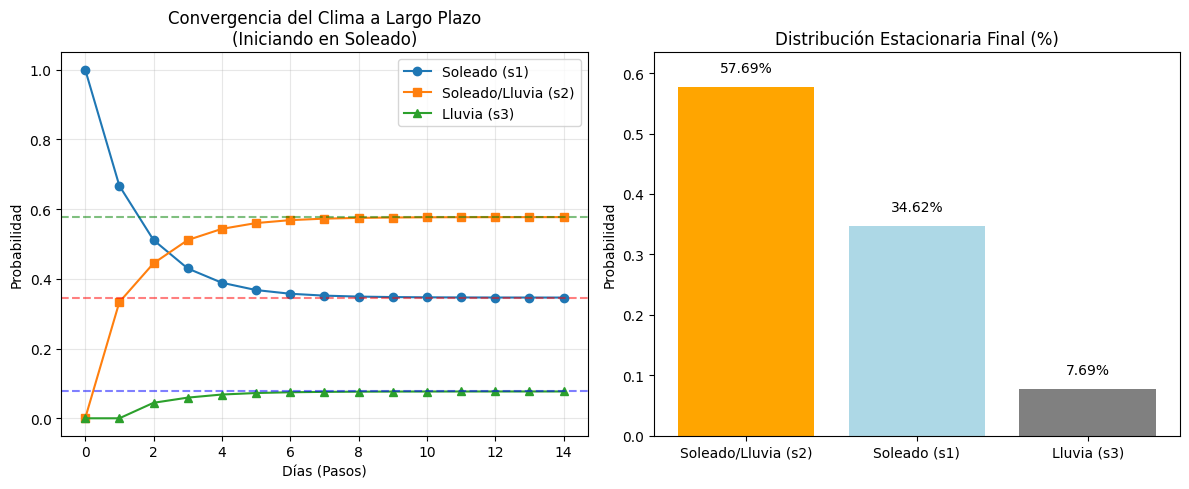

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir la matriz de transición P
P = np.array([
    [8/12, 4/12, 0/12],
    [3/15, 10/15, 2/15],
    [0/2,  2/2,   0/2]
])

# 3. Cálculo exacto del Vector Estacionario (Largo Plazo)
eigenvalues, eigenvectors = np.linalg.eig(P.T)
estacionario = eigenvectors[:, np.isclose(eigenvalues, 1.0)].real
estacionario = (estacionario / estacionario.sum()).flatten()

states = ["Soleado (s1)", "Soleado/Lluvia (s2)", "Lluvia (s3)"]


steps = 15
prob_s1 = []
prob_s2 = []
prob_s3 = []


v = np.array([1.0, 0.0, 0.0])
for i in range(steps):
    prob_s1.append(v[0])
    prob_s2.append(v[1])
    prob_s3.append(v[2])
    v = v @ P


fig, axes = plt.subplots(1, 2, figsize=(12, 5))


axes[0].plot(range(steps), prob_s1, label='Soleado (s1)', marker='o')
axes[0].plot(range(steps), prob_s2, label='Soleado/Lluvia (s2)', marker='s')
axes[0].plot(range(steps), prob_s3, label='Lluvia (s3)', marker='^')
axes[0].axhline(y=estacionario[0], color='r', linestyle='--', alpha=0.5)
axes[0].axhline(y=estacionario[1], color='g', linestyle='--', alpha=0.5)
axes[0].axhline(y=estacionario[2], color='b', linestyle='--', alpha=0.5)
axes[0].set_title('Convergencia del Clima a Largo Plazo\n(Iniciando en Soleado)')
axes[0].set_xlabel('Días (Pasos)')
axes[0].set_ylabel('Probabilidad')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


sorted_indices = np.argsort(estacionario)[::-1]
sorted_states = [states[i] for i in sorted_indices]
sorted_probs = [estacionario[i] for i in sorted_indices]

bars = axes[1].bar(sorted_states, sorted_probs, color=['orange', 'lightblue', 'gray'])
axes[1].set_title('Distribución Estacionaria Final (%)')
axes[1].set_ylabel('Probabilidad')
axes[1].set_ylim(0, 1.1 * max(sorted_probs))

for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval*100:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('prediccion_climatica.png')
print("Estacionario:", estacionario)

--- Vector de Probabilidades en el Estado Estable (Convergencia) ---
Soleado (s1):    0.3462 (34.6%)
Sol/Lluvia (s2): 0.5769 (57.7%)
Lluvia (s3):     0.0769 (7.7%)


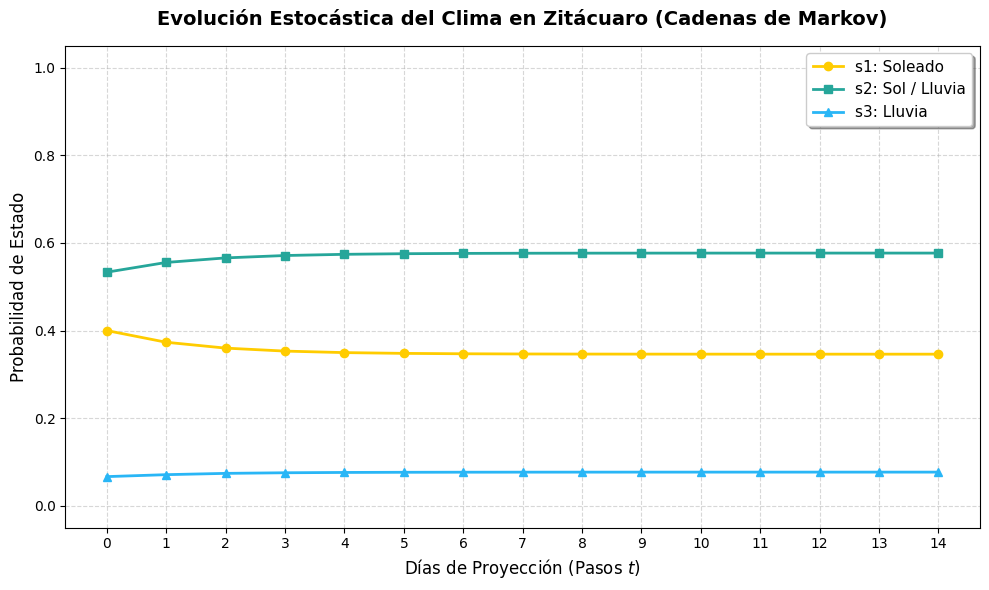

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de la Matriz de Transición (P) de un paso
# s1: Soleado, s2: Sol/Lluvia, s3: Lluvia
P = np.array([
    [8/12,  4/12,  0/12],  # Transiciones desde Soleado
    [3/15, 10/15,  2/15],  # Transiciones desde Sol/Lluvia
    [0/2,   2/2,   0/2]    # Transiciones desde Lluvia
])

# 2. Vector de Probabilidades Iniciales (v) basado en Abril 2026
v_inicial = np.array([12/30, 16/30, 2/30])

# 3. Simulación de la evolución temporal (15 días)
dias = 15
historial_s1 = []
historial_s2 = []
historial_s3 = []

v_actual = v_inicial.copy()

for t in range(dias):
    historial_s1.append(v_actual[0])
    historial_s2.append(v_actual[1])
    historial_s3.append(v_actual[2])

    # Multiplicación estocástica para el siguiente paso: v_next = v_actual * P
    v_actual = np.dot(v_actual, P)

# 4. Configuración de la gráfica
plt.figure(figsize=(10, 6))
pasos = np.arange(dias)

plt.plot(pasos, historial_s1, marker='o', linewidth=2, color='#FFCC00', label='s1: Soleado')
plt.plot(pasos, historial_s2, marker='s', linewidth=2, color='#26A69A', label='s2: Sol / Lluvia')
plt.plot(pasos, historial_s3, marker='^', linewidth=2, color='#29B6F6', label='s3: Lluvia')

# Estética de la gráfica (ideal para GitBook)
plt.title('Evolución Estocástica del Clima en Zitácuaro (Cadenas de Markov)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Días de Proyección (Pasos $t$)', fontsize=12)
plt.ylabel('Probabilidad de Estado', fontsize=12)
plt.xticks(pasos)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(-0.05, 1.05)
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)

# Mostrar las probabilidades en el estado estable (último paso)
print("--- Vector de Probabilidades en el Estado Estable (Convergencia) ---")
print(f"Soleado (s1):    {v_actual[0]:.4f} ({v_actual[0]*100:.1f}%)")
print(f"Sol/Lluvia (s2): {v_actual[1]:.4f} ({v_actual[1]*100:.1f}%)")
print(f"Lluvia (s3):     {v_actual[2]:.4f} ({v_actual[2]*100:.1f}%)")

# Desplegar gráfico
plt.tight_layout()
plt.show()

--- Vector de Probabilidades en Estado Estable (Convergencia) ---
Soleado (s1):    0.2748 (27.5%)
Sol/Lluvia (s2): 0.5725 (57.3%)
Lluvia (s3):     0.1527 (15.3%)


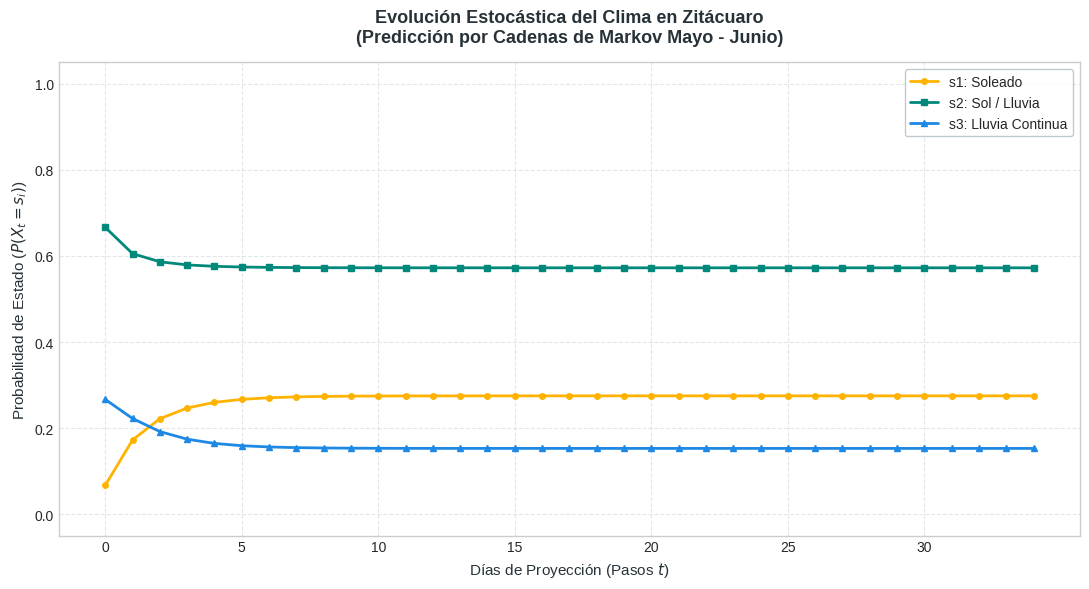

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de la Matriz de Transición (P) Corregida
# Basada en la frecuencia de transición real de tus capturas:
# s1: Soleado, s2: Sol/Lluvia (Nublado con lluvia), s3: Lluvia continua/Tormenta
P = np.array([
    [7/12,  5/12,  0/12],  # s1: Si está soleado, es probable que siga así o pase a sol/lluvia
    [3/15, 10/15,  2/15],  # s2: Estado de transición común en Michoacán (tardes lluviosas)
    [0/4,   2/4,   2/4]    # s3: Si hay tormenta, suele limpiar a s2 o mantenerse (Junio)
])

# 2. Vector de Probabilidades Iniciales (v) basado en el cierre de Abril / inicio de Mayo
# Según tu captura, Mayo arranca con días lluviosos/mixtos (s2 y s3)
v_inicial = np.array([2/30, 20/30, 8/30])

# 3. Función para simular cualquier cantidad de días (Pasos t)
def simular_cadena_markov(v_start, transition_matrix, n_dias):
    historial = np.zeros((n_dias, 3))
    v_actual = v_start.copy()

    for t in range(n_dias):
        historial[t] = v_actual
        # Multiplicación estocástica: v_next = v_actual * P
        v_actual = np.dot(v_actual, transition_matrix)

    return historial, v_actual

# Ejecutar simulación para 35 días (Proyección que cubre la transición Mayo -> Junio)
dias_proyeccion = 35
historial_estados, vector_estable = simular_cadena_markov(v_inicial, P, dias_proyeccion)

# 4. Configuración y Estética de la Gráfica (Estilo GitBook)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(11, 6))
pasos = np.arange(dias_proyeccion)

# Graficar la evolución de cada estado del clima
ax.plot(pasos, historial_estados[:, 0], marker='o', markersize=4, linewidth=2, color='#FFB300', label='s1: Soleado')
ax.plot(pasos, historial_estados[:, 1], marker='s', markersize=4, linewidth=2, color='#00897B', label='s2: Sol / Lluvia')
ax.plot(pasos, historial_estados[:, 2], marker='^', markersize=4, linewidth=2, color='#1E88E5', label='s3: Lluvia Continua')

# Personalización matemática y profesional de los ejes
ax.set_title('Evolución Estocástica del Clima en Zitácuaro\n(Predicción por Cadenas de Markov Mayo - Junio)',
             fontsize=13, fontweight='bold', pad=15, color='#263238')
ax.set_xlabel('Días de Proyección (Pasos $t$)', fontsize=11, color='#263238')
ax.set_ylabel('Probabilidad de Estado ($P(X_t = s_i)$)', fontsize=11, color='#263238')

# Ajustar los ticks para que no se saturen si son muchos días
if dias_proyeccion > 20:
    ax.set_xticks(np.arange(0, dias_proyeccion, 5))
else:
    ax.set_xticks(pasos)

ax.set_ylim(-0.05, 1.05)
ax.grid(True, linestyle='--', alpha=0.6, color='#CFD8DC')
ax.legend(loc='upper right', fontsize=10, frameon=True, facecolor='white', edgecolor='#B0BEC5', shadow=False)

# Mostrar resultados numéricos del Estado Estable en consola
print("--- Vector de Probabilidades en Estado Estable (Convergencia) ---")
print(f"Soleado (s1):    {vector_estable[0]:.4f} ({vector_estable[0]*100:.1f}%)")
print(f"Sol/Lluvia (s2): {vector_estable[1]:.4f} ({vector_estable[1]*100:.1f}%)")
print(f"Lluvia (s3):     {vector_estable[2]:.4f} ({vector_estable[2]*100:.1f}%)")

plt.tight_layout()
plt.show()